# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
## **Práctica 5: Introducción al análisis frecuencial de señales**
### Laboratorio Bioseñales y sistemas
- Alejandra Hinestroza Chaparro
- María José Ríos Hurtado

### _Resumen_

### _Marco Teórico_

### _Desarrollo_

**1. Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente. (10%)**

El Teorema de Nyquist dice que para poder representar correctamente una señal sin distorsionarla, la frecuencia de muestreo debe ser al menos el doble de la frecuencia más alta que contiene la señal.

La frecuencia más alta de las tres componentes solicitadas es 160 Hz, entonces:

_**Fs_mínima =** 2 × 160 = 320 Hz_

Pero en la práctica siempre se usa un poco más para tener margen. Se usará _**Fs = 2000 Hz**_, equivalente a 12.5 veces la frecuencia más alta de la señal (160 Hz), lo que garantiza una representación visual suave y cumple ampliamente el criterio de Nyquist con un margen de seguridad adecuado.

Cada sinusoide tiene su propio período:

- **F₁ =** 40 Hz → T₁ = 1/40 = 0.025 s
- **F₂ =** 80 Hz → T₂ = 1/80 = 0.0125 s
- **F₃ =** 160 Hz → T₃ = 1/160 = 0.00625 s

Para que la señal combinada "cierre" un ciclo completo, se usará el período de la componente más lenta (40 Hz), porque las otras dos caben exactamente dentro de él (80 Hz cabe 2 veces, 160 Hz cabe 4 veces).

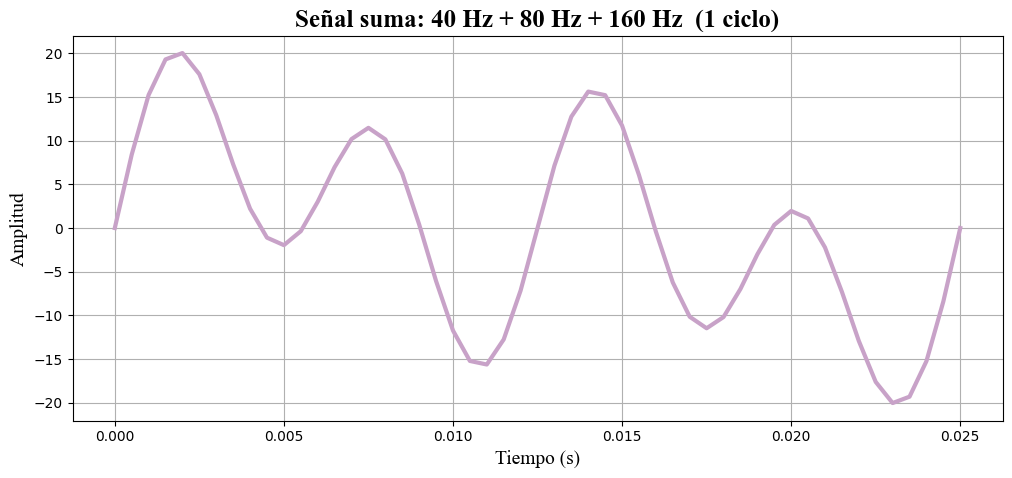

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Frecuencias de cada componente sinusoidal ──
F1 = 40    # Hz
F2 = 80    # Hz
F3 = 160   # Hz

# ── Frecuencia de muestreo ──
# Nyquist exige Fs > 2 * 160 = 320 Hz
# Usamos 2000 Hz para tener buena resolución y números cómodos
Fs = 2000          # Hz
T  = 1 / Fs        # Período de muestreo = 0.001 s (tiempo entre muestras)

# ── Período de la señal completa ──
# La componente más lenta marca el período del conjunto
Tp = 1 / F1        # = 0.025 s (un ciclo completo de 40 Hz)

# ── Vector de tiempo para UN ciclo ──
# np.arange(inicio, fin, paso)
# Empezamos en 0, terminamos en Tp (inclusivo), con pasos de T
t = np.arange(0, Tp + T, T)

# ── Construcción de cada sinusoide ──
# La fórmula es: A * sin(2π * F * t)
# Usamos deferentes amplitudes
x1 = 5*np.sin(2 * np.pi * F1 * t)   # componente de 40 Hz
x2 = 8*np.sin(2 * np.pi * F2 * t)   # componente de 80 Hz
x3 = 12*np.sin(2 * np.pi * F3 * t)   # componente de 160 Hz

# ── Señal total: sumamos las tres ──
x = x1 + x2 + x3

# ── Graficamos ──
plt.figure(figsize=(12, 5))
plt.plot(t, x, linewidth=3, color=(200/255, 162/255, 200/255))
plt.title('Señal suma: 40 Hz + 80 Hz + 160 Hz  (1 ciclo)', fontname = 'Times New Roman', fontsize = 18, fontweight='bold')
plt.xlabel('Tiempo (s)', fontname = 'Times New Roman', fontsize = 14)
plt.ylabel('Amplitud', fontname = 'Times New Roman', fontsize = 14)
plt.grid(True)
plt.show()

**4.2 Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal). (10%)**



Número de muestras en 10 ciclos: 501


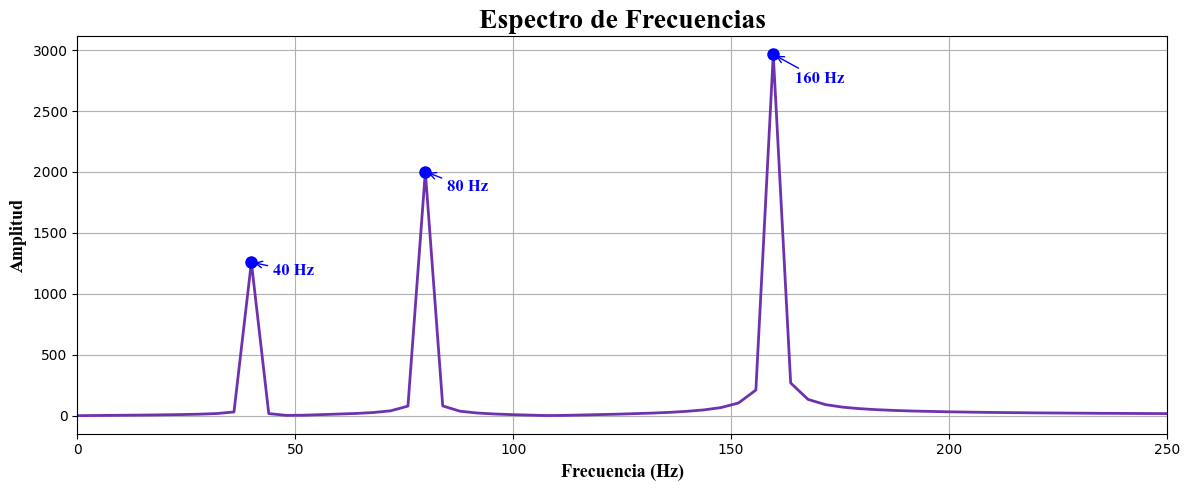

Frecuencias identificadas en el espectro:
───────────────────────────────────
  → 39.9 Hz  |  Amplitud: 1258.84
  → 79.8 Hz  |  Amplitud: 2001.19
  → 159.7 Hz  |  Amplitud: 2964.63


In [ ]:
from scipy.signal import find_peaks
# ── Crear la señal con 10 periodos ──
# Antes teníamos 1 ciclo (duración = Tp = 0.025 s)
# Ahora queremos 10 ciclos (duración = 10 * Tp = 0.25 s)

t10 = np.arange(0, 10*Tp + T, T)   # vector de tiempo para 10 ciclos

# Recreamos la señal suma pero ahora con 10 ciclos
x10 = (5*np.sin(2 * np.pi * F1 * t10) +
       8*np.sin(2 * np.pi * F2 * t10) +
       12*np.sin(2 * np.pi * F3 * t10))

print(f'Número de muestras en 10 ciclos: {len(t10)}')

# ── Calcular la DFT ──
X10 = np.fft.fft(x10)
# X10 es un vector de números complejos
# Para graficar usamos su MÓDULO (np.abs), que representa la amplitud

N = len(X10)   # número total de puntos de la DFT

# ── Crear el eje de frecuencias ──
# Cada índice k de la DFT corresponde a una frecuencia F = k * Fs / N
F_eje = np.arange(0, N) * Fs / N

# ── Solo graficamos la mitad (hasta Nyquist) ──
# La DFT es simétrica: la segunda mitad es espejo de la primera
# Solo nos interesa de 0 Hz hasta Fs/2 
Nmitad   = int(np.ceil(N / 2))
F_mitad  = F_eje[:Nmitad]
X_mitad  = X10[:Nmitad]

# ── Encontrar los picos automáticamente ──
# height=50 significa que solo detecta picos que superen esa amplitud
# así evitamos detectar "ruido" pequeño como pico
picos_idx, _ = find_peaks(np.abs(X_mitad), height=50)

# ── Graficar el espectro ──
plt.figure(figsize=(12, 5))
plt.plot(F_mitad, np.abs(X_mitad), color="#6F32AF", linewidth=2)

# ── Etiquetar cada pico encontrado ──
for idx in picos_idx:
    frecuencia = F_mitad[idx]
    amplitud   = np.abs(X_mitad[idx])
    
    # Punto rojo encima del pico
    plt.plot(frecuencia, amplitud, 'bo', markersize=8)
    
    # Etiqueta con la frecuencia
    plt.annotate(f'{frecuencia:.0f} Hz',
                 xy=(frecuencia, amplitud),        # donde apunta la flecha
                 xytext=(frecuencia + 5, amplitud * 0.92),  # donde va el texto
                 fontname='Times New Roman',
                 fontsize=12,
                 fontweight='bold',
                 color='blue',
                 arrowprops=dict(arrowstyle='->', color='blue'))

plt.title('Espectro de Frecuencias',
          fontname='Times New Roman', fontsize=20, fontweight='bold')
plt.xlabel('Frecuencia (Hz)', fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.ylabel('Amplitud',        fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.xlim(0, 250) # Zoom para ver mejor los picos
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Imprimir en consola ──
print('Frecuencias identificadas en el espectro:')
print('─' * 35)
for idx in picos_idx:
    print(f'  → {F_mitad[idx]:.1f} Hz  |  Amplitud: {np.abs(X_mitad[idx]):.2f}')

**4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior. (10%)**

La Transformada Inversa de Fourier (IFFT, por sus siglas en inglés) es la operación matemática que permite reconstruir una señal en el dominio del tiempo a partir de su representación en el dominio de la frecuencia. En Python, esta operación se implementa mediante la función **_numpy.fft.ifft()_**, la cual recibe como argumento el espectro complejo obtenido por la FFT y devuelve la señal reconstruida. Dado que los cálculos computacionales introducen pequeños errores de redondeo del orden de 10⁻¹⁵, el resultado puede contener una parte imaginaria despreciable, por lo que se extrae únicamente la parte real mediante **_numpy.real()_**. Si la señal original es real y el espectro fue calculado correctamente, la señal reconstruida debe ser numéricamente idéntica a la original, lo cual puede verificarse con la función **_numpy.allclose()_**. [1]

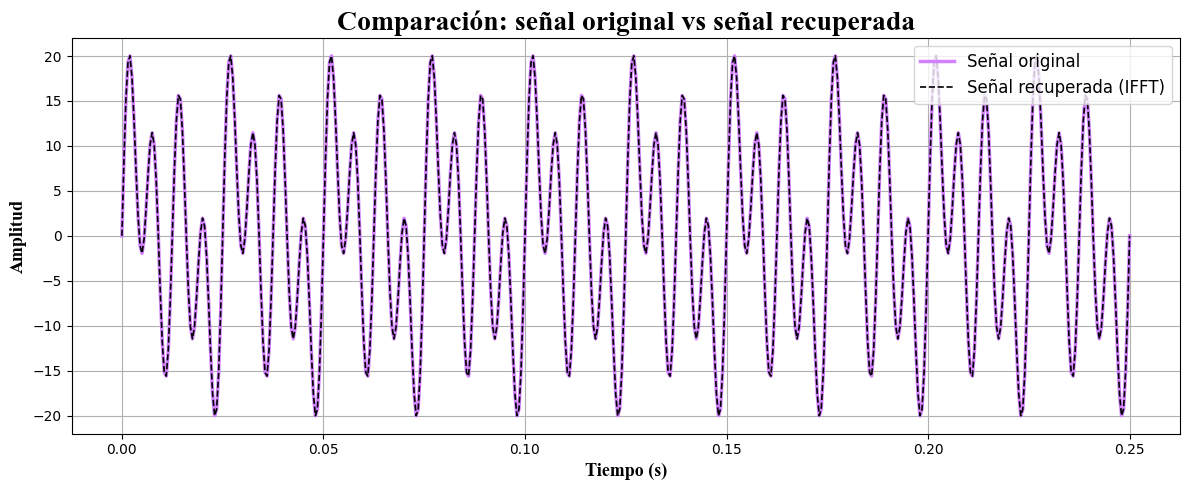

¿La señal recuperada es igual a la original? True


In [7]:
# ── Aplicar la transformada inversa ──
# Le pasamos el espectro completo X10 (no la mitad)
# porque la IFFT necesita toda la información para reconstruir
x_recuperada = np.fft.ifft(X10)

# ── Tomar solo la parte real ──
# El resultado tiene una parte imaginaria pequeñísima
# (del orden de 10^-15) causada por errores de redondeo del computador
# En teoría debería ser cero, así que la descartamos
x_recuperada = np.real(x_recuperada)

# ── Comparar visualmente con la señal original ──
plt.figure(figsize=(12, 5))

# Graficamos la señal original
plt.plot(t10, x10,
         color="#D381FF", linewidth=2.5,
         label='Señal original')

# Graficamos la señal recuperada encima (con línea punteada)
plt.plot(t10, x_recuperada,
         color='black', linewidth=1.2,
         linestyle='--', label='Señal recuperada (IFFT)')

plt.title('Comparación: señal original vs señal recuperada',
          fontname='Times New Roman', fontsize=20, fontweight='bold')
plt.xlabel('Tiempo (s)', fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.ylabel('Amplitud',   fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Verificar numéricamente que son iguales ──
# np.allclose compara dos arreglos elemento por elemento
# y devuelve True si todos son prácticamente iguales
son_iguales = np.allclose(x10, x_recuperada)
print(f'¿La señal recuperada es igual a la original? {son_iguales}')

**4.4 ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué? (10%)**

_F1 = np.fft.fft(x);_ 

_F2 = np.zeros((len(F1)));_

_F2[9:13] = F1[9:13];_ 

_xr = np.fft.ifft(F2);_

_fig = plt.figure()_

_ax = fig.add_subplot(111)_

_ax.plot(t, np.real(xr))_

_ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');_

_plt.show()_

**Extraiga de manera similar cada una de las componentes de la señal.**

El código presentado implementa un filtro pasa-banda en el dominio de la frecuencia. Mediante la FFT se obtiene el espectro completo de la señal, luego se construye un vector de ceros del mismo tamaño y se copian únicamente los coeficientes espectrales correspondientes a los índices 9 a 12, anulando el resto. Al aplicar la IFFT sobre este espectro modificado, se obtiene una señal reconstruida que contiene exclusivamente las componentes frecuenciales seleccionadas. Este procedimiento es equivalente a multiplicar el espectro por una función rectangular (ventana) centrada en la banda de interés, lo cual es la definición de un filtro ideal pasa-banda [2].

Índices de nuestras frecuencias:
────────────────────────────────────────
  40  Hz  →  k = 1
  80  Hz  →  k = 2
  160 Hz  →  k = 4


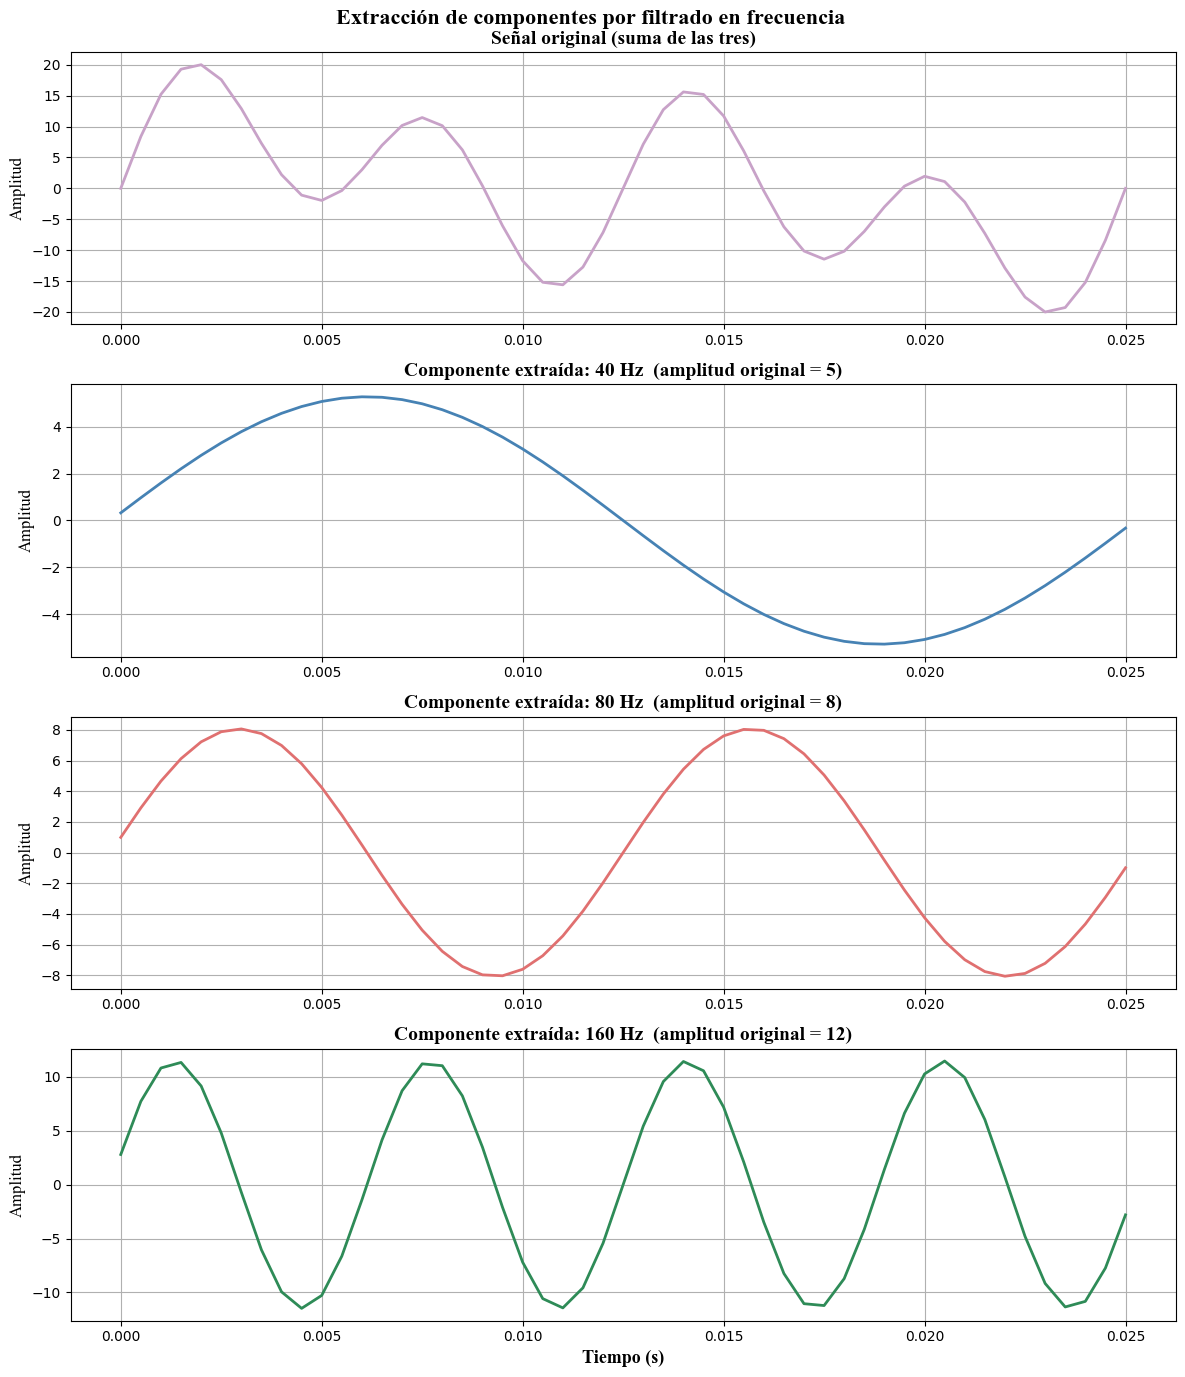

Verificación de amplitudes extraídas:
────────────────────────────────────────
  40  Hz  →  amplitud recuperada: 5.27  (esperada: 5)
  80  Hz  →  amplitud recuperada: 8.06  (esperada: 8)
  160 Hz  →  amplitud recuperada: 11.47  (esperada: 12)


In [9]:
# ── Calcular la FFT de la señal de 1 ciclo ──
FFT_x = np.fft.fft(x)
N_x   = len(FFT_x)    # número de muestras de la señal

# ── Calcular los índices correctos para nuestras frecuencias ──
# Con Fs=2000 Hz, los índices cambian respecto a la guía
k_40  = int(round(F1 * N_x / Fs))
k_80  = int(round(F2 * N_x / Fs))
k_160 = int(round(F3 * N_x / Fs))

print('Índices de nuestras frecuencias:')
print('─' * 40)
print(f'  40  Hz  →  k = {k_40}')
print(f'  80  Hz  →  k = {k_80}')
print(f'  160 Hz  →  k = {k_160}')

# ── Extraer componente de 40 Hz ──
# Creamos vector de ceros tipo complex porque la FFT es compleja
F_filtro_40             = np.zeros(N_x, dtype=complex)
F_filtro_40[k_40]       = FFT_x[k_40]          # lado izquierdo del espectro
F_filtro_40[N_x - k_40] = FFT_x[N_x - k_40]   # lado derecho (simetría)
comp_40 = np.real(np.fft.ifft(F_filtro_40))

# ── Extraer componente de 80 Hz ──
F_filtro_80             = np.zeros(N_x, dtype=complex)
F_filtro_80[k_80]       = FFT_x[k_80]
F_filtro_80[N_x - k_80] = FFT_x[N_x - k_80]
comp_80 = np.real(np.fft.ifft(F_filtro_80))

# ── Extraer componente de 160 Hz ──
F_filtro_160              = np.zeros(N_x, dtype=complex)
F_filtro_160[k_160]       = FFT_x[k_160]
F_filtro_160[N_x - k_160] = FFT_x[N_x - k_160]
comp_160 = np.real(np.fft.ifft(F_filtro_160))

fig, axes = plt.subplots(4, 1, figsize=(12, 14))

# Señal original arriba para comparar
axes[0].plot(t, x, color='#C8A2C8', linewidth=2)
axes[0].set_title('Señal original (suma de las tres)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12)
axes[0].grid(True)

# Componente 40 Hz
axes[1].plot(t, comp_40, color='steelblue', linewidth=2)
axes[1].set_title('Componente extraída: 40 Hz  (amplitud original = 5)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12)
axes[1].grid(True)

# Componente 80 Hz
axes[2].plot(t, comp_80, color='#E07070', linewidth=2)
axes[2].set_title('Componente extraída: 80 Hz  (amplitud original = 8)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12)
axes[2].grid(True)

# Componente 160 Hz
axes[3].plot(t, comp_160, color='seagreen', linewidth=2)
axes[3].set_title('Componente extraída: 160 Hz  (amplitud original = 12)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12)
axes[3].set_xlabel('Tiempo (s)', fontname='Times New Roman', fontsize=13, fontweight='bold')
axes[3].grid(True)

plt.suptitle('Extracción de componentes por filtrado en frecuencia',
             fontname='Times New Roman', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Verificar que las amplitudes son correctas ──
print('Verificación de amplitudes extraídas:')
print('─' * 40)
print(f'  40  Hz  →  amplitud recuperada: {np.max(np.abs(comp_40)):.2f}  (esperada: 5)')
print(f'  80  Hz  →  amplitud recuperada: {np.max(np.abs(comp_80)):.2f}  (esperada: 8)')
print(f'  160 Hz  →  amplitud recuperada: {np.max(np.abs(comp_160)):.2f}  (esperada: 12)')

**4.5 El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja) (25%)** 

**4.6 Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja) (25%)**

### _Análisis de resultados y discusión_

### _Conclusiones_

### _Referencias_

[1] NumPy Developers. (2024). numpy.fft.ifft. NumPy Documentation. https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html

[2] J. G. Proakis, D.G. Manolakis, Digital Signal Processing. Principles and Applications, 4th ed, pag. 75-77, Ed. Prentice Hall, 2007.